# Overview
> In this phase, webscraping amazon is the main goal.

The study shall make use of selenium and BeautifulSoup to create an etl system that can scrape data from amazon.com
and use aws s3 as storage.

# Extract
Here we scrape the data from amazon.com

In [13]:
# Importing dependencies
from selenium import webdriver
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from tqdm import tqdm
import random
import time
import warnings
warnings.filterwarnings("ignore")

from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver import ChromeOptions
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver import ChromeOptions
from selenium.common.exceptions import TimeoutException, NoSuchElementException

from bs4 import BeautifulSoup
import requests
import re
import boto3
import getpass
import json
import os

from etl import initialize_driver, perform_actions, find_dept_divisions, scrape_dept
from etl import concat_dfs, save_dept_json, export_data_to_s3, make_df, preprocess_text
import logging

# Configure the logging level for TensorFlow and spaCy
logging.getLogger("tensorflow").setLevel(logging.ERROR)
logging.getLogger("spacy").setLevel(logging.ERROR)

import spacy

In [2]:
# base url
url = "https://www.amazon.com/"

In [3]:
# Initialize the driver
driver = initialize_driver()

# Perform actions
perform_actions(driver, url)

TypeError: __init__() got multiple values for argument 'options'

In [4]:
# Get all departments
all_deps = driver.find_element(By.XPATH, "//html/body/div[3]/div[2]/div/ul[1]")

# Click see all to see all the departments
see_all = all_deps.find_element(By.XPATH, "//*[@id='hmenu-content']/ul[1]/li[11]/a[1]")
if see_all.text == 'See All':
    see_all.click()

In [5]:
# get the list of all the departments
departments = all_deps.find_elements(By.CLASS_NAME, 'hmenu-item')
department_names = [department.text for department in departments]
department_names

['Digital Content & Devices',
 'Amazon Music',
 'Kindle E-readers & Books',
 'Amazon Appstore',
 'Shop By Department',
 'Electronics',
 'Computers',
 'Smart Home',
 'Arts & Crafts',
 'Automotive',
 'Baby',
 'Beauty and personal care',
 "Women's Fashion",
 "Men's Fashion",
 "Girls' Fashion",
 "Boys' Fashion",
 'Health and Household',
 'Home and Kitchen',
 'Industrial and Scientific',
 'Luggage',
 'Movies & Television',
 'Pet supplies',
 'Software',
 'Sports and Outdoors',
 'Tools & Home Improvement',
 'Toys and Games',
 'Video Games',
 '',
 'See Less',
 'Programs & Features',
 'Gift Cards',
 'Shop By Interest',
 'Amazon Live',
 'International Shopping',
 '',
 'See All',
 '',
 'Help & Settings',
 'Your Account',
 'English',
 'United States',
 'Customer Service',
 'Sign in']

In [6]:
# filter departments
departments_of_interest = department_names[5:27]
departments_to_scrape = departments[5:27]
departments_of_interest

['Electronics',
 'Computers',
 'Smart Home',
 'Arts & Crafts',
 'Automotive',
 'Baby',
 'Beauty and personal care',
 "Women's Fashion",
 "Men's Fashion",
 "Girls' Fashion",
 "Boys' Fashion",
 'Health and Household',
 'Home and Kitchen',
 'Industrial and Scientific',
 'Luggage',
 'Movies & Television',
 'Pet supplies',
 'Software',
 'Sports and Outdoors',
 'Tools & Home Improvement',
 'Toys and Games',
 'Video Games']

In [7]:
# create a dictionary of department names and their respective web elements
deps_dict = dict(zip(departments_of_interest, departments_to_scrape))
print(deps_dict.keys())

dict_keys(['Electronics', 'Computers', 'Smart Home', 'Arts & Crafts', 'Automotive', 'Baby', 'Beauty and personal care', "Women's Fashion", "Men's Fashion", "Girls' Fashion", "Boys' Fashion", 'Health and Household', 'Home and Kitchen', 'Industrial and Scientific', 'Luggage', 'Movies & Television', 'Pet supplies', 'Software', 'Sports and Outdoors', 'Tools & Home Improvement', 'Toys and Games', 'Video Games'])


In [8]:
# Get department
departments_of_interest[12]

'Home and Kitchen'

In [9]:
# Get the divisions in the departmment
home_dict = find_dept_divisions(departments_of_interest[12], deps_dict, driver)
print(home_dict.keys())

valid department
dict_keys(["Kids' Home Store", 'Kitchen & Dining', 'Bedding', 'Bath', 'Furniture', 'Home Décor', 'Wall Art', 'Lighting & Ceiling Fans', 'Seasonal Décor', 'Event & Party Supplies', 'Heating, Cooling & Air Quality', 'Irons & Steamers', 'Vacuums & Floor Care', 'Storage & Organization', 'Cleaning Supplies'])


In [10]:
# scrape the department
home_dept = scrape_dept(home_dict, driver)

Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Timeout exception - did not find product, exiting loop
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found


Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not f

Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Timeout exception - did not find product, exiting loop
Timeout exception - did not find product, exiting loop
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item 

Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not found
Item not f

WebDriverException: Message: unknown error: net::ERR_NAME_NOT_RESOLVED
  (Session info: chrome=118.0.5993.117)
Stacktrace:
#0 0x55a8256d0a93 <unknown>
#1 0x55a8253bc217 <unknown>
#2 0x55a8253b4323 <unknown>
#3 0x55a8253a4db9 <unknown>
#4 0x55a8253a6241 <unknown>
#5 0x55a8253a51b7 <unknown>
#6 0x55a8253a416f <unknown>
#7 0x55a8253a4111 <unknown>
#8 0x55a8253a2dee <unknown>
#9 0x55a8253a325a <unknown>
#10 0x55a8253be8be <unknown>
#11 0x55a82543dab5 <unknown>
#12 0x55a8254242a2 <unknown>
#13 0x55a82543d49c <unknown>
#14 0x55a825424073 <unknown>
#15 0x55a8253f7022 <unknown>
#16 0x55a8253f7e0e <unknown>
#17 0x55a825699c4d <unknown>
#18 0x55a82569dda4 <unknown>
#19 0x55a8256a6fe8 <unknown>
#20 0x55a82569e5c0 <unknown>
#21 0x55a82566e6de <unknown>
#22 0x55a8256bf528 <unknown>
#23 0x55a8256bf724 <unknown>
#24 0x55a8256cfbb8 <unknown>
#25 0x7f056e3cbb43 <unknown>


In [14]:
# Check the length of each division
total_items = []

for key, val in health_dept.items():
    print(key)
    print(len(health_dept[key]))
    key_len = len(health_dept[key])
    total_items.append(key_len)
    print("-"*30)
    
print(f"Total:{sum(total_items)} items")

Baby & Child Care
5194
------------------------------
Health Care
2342
------------------------------
Household Supplies
2800
------------------------------
Medical Supplies & Equipment
4203
------------------------------
Oral Care
2557
------------------------------
Personal Care
5917
------------------------------
Sexual Wellness
524
------------------------------
Sports Nutrition
1035
------------------------------
Stationery & Gift Wrapping Supplies
3983
------------------------------
Vision Care
3119
------------------------------
Vitamins & Dietary Supplements
88
------------------------------
Wellness & Relaxation
4078
------------------------------
Total:35840 items


# Transform
In this section, preprocessing shall take place; cleaning, formatting and aggregating the data.

In [3]:
# create a data frame from all the existing json files
df = concat_dfs('data/')

# preview
df

Loaded data from computers.json
Loaded data from automative.json
Loaded data from beauty.json
Loaded data from health_household.json
Loaded data from baby.json
Loaded data from art.json
Loaded data from electronics.json


,name,mean_rating,num_ratings,price,division,department
0,"USB 3.0 Hub, INTPW 4 Port USB 3.0 Hub Multipor...",4.5,56,8.39,Computer Accessories & Peripherals,computers
1,"Imegny RGB Gaming Mouse Pad,900x400mm XXXL Ext...",4.8,41,20.99,Computer Accessories & Peripherals,computers
2,Eazy2hD 15U Open Frame Network Rack for Server...,3.9,3,129.99,Computer Accessories & Peripherals,computers
3,"Elebase USB to USB C Adapter 4 Pack,Type C Fem...",4.6,"32,687",9.99,Computer Accessories & Peripherals,computers
4,HP 63XL Black High-yield Ink Cartridge | Works...,4.7,"49,778",45.89,Computer Accessories & Peripherals,computers
...,...,...,...,...,...,...
365160,"Ebook Reader, 7inch TFT LCD E-book Reader, Dig...",2.7,4,66.14,eBook Readers & Accessories,electronics
365161,TiMOVO Sleeve Case for 6.8 inch All-New Kindle...,5.0,2,13.99,eBook Readers & Accessories,electronics
365162,kwmobile Cover Compatible with Kobo Libra H2O ...,5.0,3,12.99,eBook Readers & Accessories,electronics
365163,BoxWave Cable Compatible with Amazon Kindle Oa...,5.0,1,14.95,eBook Readers & Accessories,electronics


### Preliminary inspection and data preparation

In [4]:
# metadata
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365165 entries, 0 to 365164
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   name         365165 non-null  object
 1   mean_rating  365165 non-null  object
 2   num_ratings  365165 non-null  object
 3   price        365165 non-null  object
 4   division     365165 non-null  object
 5   department   365165 non-null  object
dtypes: object(6)
memory usage: 16.7+ MB


In [5]:
print(f"There are {df.duplicated().sum()} duplicates")

There are 92826 duplicates


### Data Description:
There are 6 columns in this data:
* `name` ~ name of the product
* `mean_rating` ~ mean rating of the product
* `num_ratings` ~ number of users who have rated the product
* `price` ~ price (in USD) of the product
* `division` ~ the amazon department division to which the product belongs e.g wearable technology, accessories & supplies
* `department` ~ the department in which the product belongs e.g electronics, computers, men's fashion etc.

#### Observations:
* All the columns are strings yet some columns like price, mean_rating and num_ratings should be numeric columns
* There are no missing values in this data.
* There are 92826 duplicates in this data.

In [5]:
# Type casting columns to numeric
df['price'] = df['price'].str.replace(",", "").astype('float')
df['mean_rating'] = df['mean_rating'].astype('float')
df['num_ratings'] = df['num_ratings'].str.replace(",", "").astype(int)

# preview
df.tail()

,name,mean_rating,num_ratings,price,division,department
365160,"Ebook Reader, 7inch TFT LCD E-book Reader, Dig...",2.7,4,66.14,eBook Readers & Accessories,electronics
365161,TiMOVO Sleeve Case for 6.8 inch All-New Kindle...,5.0,2,13.99,eBook Readers & Accessories,electronics
365162,kwmobile Cover Compatible with Kobo Libra H2O ...,5.0,3,12.99,eBook Readers & Accessories,electronics
365163,BoxWave Cable Compatible with Amazon Kindle Oa...,5.0,1,14.95,eBook Readers & Accessories,electronics
365164,TiMOVO [3 Pack Anti-Glare Screen Protector Des...,2.0,2,10.99,eBook Readers & Accessories,electronics


In [6]:
# Remove duplicates
df = df.drop_duplicates()

# preview
df

,name,mean_rating,num_ratings,price,division,department
0,"USB 3.0 Hub, INTPW 4 Port USB 3.0 Hub Multipor...",4.5,56,8.39,Computer Accessories & Peripherals,computers
1,"Imegny RGB Gaming Mouse Pad,900x400mm XXXL Ext...",4.8,41,20.99,Computer Accessories & Peripherals,computers
2,Eazy2hD 15U Open Frame Network Rack for Server...,3.9,3,129.99,Computer Accessories & Peripherals,computers
3,"Elebase USB to USB C Adapter 4 Pack,Type C Fem...",4.6,32687,9.99,Computer Accessories & Peripherals,computers
4,HP 63XL Black High-yield Ink Cartridge | Works...,4.7,49778,45.89,Computer Accessories & Peripherals,computers
...,...,...,...,...,...,...
365155,BoxWave Case Compatible with Pocketbook Touch ...,5.0,1,25.95,eBook Readers & Accessories,electronics
365156,PocketBook Cover for InkPad X | Black | PU Lea...,3.9,7,21.13,eBook Readers & Accessories,electronics
365157,kwmobile Case Compatible with Kobo Libra H2O -...,4.7,5,12.99,eBook Readers & Accessories,electronics
365158,kwmobile Case Compatible with Kobo Libra 2 Cas...,4.1,13,11.99,eBook Readers & Accessories,electronics


In [7]:
# preprocess 'name'
df[df['name'] == 'Magnetic Wireless Charging Station for Apple Series, 3-in-1 15W Fast Mag-Safe Charger Stand with QC3.0 Adapter, for iPhone 15, 14,13,12 Pro Max/Pro/Mini/Plus, iWatch Ultra/9/8/7/6/5/4/3/2, AirPods\u2026']

,name,mean_rating,num_ratings,price,division,department
317051,Magnetic Wireless Charging Station for Apple S...,4.3,9108,39.99,Accessories & Supplies,electronics
325435,Magnetic Wireless Charging Station for Apple S...,4.3,9108,39.99,Cell Phones & Accessories,electronics


In [8]:
# Check duplicates once more by subsetting on 'name'
df['name'].duplicated().sum()

34481

In [9]:
# Remove duplicates based on name
df = df.drop_duplicates(subset=['name'])

# preview
df

,name,mean_rating,num_ratings,price,division,department
0,"USB 3.0 Hub, INTPW 4 Port USB 3.0 Hub Multipor...",4.5,56,8.39,Computer Accessories & Peripherals,computers
1,"Imegny RGB Gaming Mouse Pad,900x400mm XXXL Ext...",4.8,41,20.99,Computer Accessories & Peripherals,computers
2,Eazy2hD 15U Open Frame Network Rack for Server...,3.9,3,129.99,Computer Accessories & Peripherals,computers
3,"Elebase USB to USB C Adapter 4 Pack,Type C Fem...",4.6,32687,9.99,Computer Accessories & Peripherals,computers
4,HP 63XL Black High-yield Ink Cartridge | Works...,4.7,49778,45.89,Computer Accessories & Peripherals,computers
...,...,...,...,...,...,...
365155,BoxWave Case Compatible with Pocketbook Touch ...,5.0,1,25.95,eBook Readers & Accessories,electronics
365156,PocketBook Cover for InkPad X | Black | PU Lea...,3.9,7,21.13,eBook Readers & Accessories,electronics
365157,kwmobile Case Compatible with Kobo Libra H2O -...,4.7,5,12.99,eBook Readers & Accessories,electronics
365158,kwmobile Case Compatible with Kobo Libra 2 Cas...,4.1,13,11.99,eBook Readers & Accessories,electronics


#### Observations:
The study has noted that some characters, while not standard are names of certain products or part of their names e.g 'tn7602pk' is a printer and there are also products like 'samsung s22+' - if the '+' is removed then it would be wrong because there is also a 'samsung s22' and these two items are different. There are also product dimensions like '(49mm)' and '(8.9 in. 11.4 in)' to show the product details. If that is altered then the study shall have removed some of the unique identifiers of these products.

The study will only remove noise (non-standard characters) because if stopwords are removed then products like "in-ear headphones with built-in microphones" will lose a lot of information, lemmatization will also convert a word like "built" to build.

## Text Preprocessing

In [10]:
# declare nlp
nlp = spacy.load("en_core_web_sm")

In [11]:
# Inspecting the preprocessing
df['name'] = df['name'].apply(preprocess_text)
df

,name,mean_rating,num_ratings,price,division,department
0,"usb 3.0 hub, intpw 4 port usb 3.0 hub multipor...",4.5,56,8.39,Computer Accessories & Peripherals,computers
1,"imegny rgb gaming mouse pad,900x400mm xxxl ext...",4.8,41,20.99,Computer Accessories & Peripherals,computers
2,eazy2hd 15u open frame network rack for server...,3.9,3,129.99,Computer Accessories & Peripherals,computers
3,"elebase usb to usb c adapter 4 pack,type c fem...",4.6,32687,9.99,Computer Accessories & Peripherals,computers
4,hp 63xl black high-yield ink cartridge | works...,4.7,49778,45.89,Computer Accessories & Peripherals,computers
...,...,...,...,...,...,...
365155,boxwave case compatible with pocketbook touch ...,5.0,1,25.95,eBook Readers & Accessories,electronics
365156,pocketbook cover for inkpad x | black | pu lea...,3.9,7,21.13,eBook Readers & Accessories,electronics
365157,kwmobile case compatible with kobo libra h2o -...,4.7,5,12.99,eBook Readers & Accessories,electronics
365158,kwmobile case compatible with kobo libra 2 cas...,4.1,13,11.99,eBook Readers & Accessories,electronics


## EDA
> In this phase the study shall perfom some basic exploratory data analysis to get the patterns within the data.

Some of the questions to be answered by the EDA include:
* Which is the most expensive product in the data?
* Which is the most expensive department in the data?
* Which is the most rated product and which product has the highest mean rating?
* Which department has the highest mean rating?
* Which department has the most products?

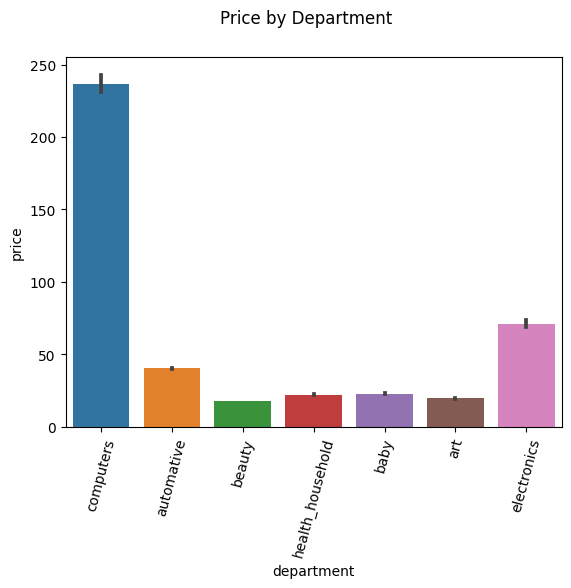

In [27]:
# Which is the most expensive department in the data?
sns.barplot(data=df, x='department', y = 'price')
plt.suptitle("Price by Department")
plt.xticks(rotation=75)
plt.show()

In [36]:
# Which is the most expensive product in the data
top_10_expensive = df.sort_values(by='price', ascending=False).head(10)

# plt.figure(figsize=(12, 6))
# sns.barplot(data=top_10_expensive, x='name', y='price')
# plt.title("Top 10 Most Expensive Products")
# plt.xticks(rotation=75)
# plt.show()

# The plot does not look great so the study shall preview as a dataframe
top_10_expensive

,name,mean_rating,num_ratings,price,division,department
351181,sony vpl-xw6000es 4k hdr laser home theater pr...,5.0,5,11998.00,Video Projectors,electronics
339218,"autel drone robotics evo max 4t, visiable/ zoo...",5.0,1,8959.00,Security & Surveillance,electronics
351084,lg hu915qe ultra short throw 4k uhd (3840 x 21...,3.4,8,5999.99,Video Projectors,electronics
350908,sony vpl-xw5000es 4k hdr laser home theater pr...,4.7,19,5998.00,Video Projectors,electronics
323400,nikon z 9 | flagship professional full-frame s...,4.5,79,5496.95,Camera & Photo,electronics
15531,ridgid 57288 cs12x digital recording monitor,5.0,2,5481.83,Monitors,computers
18827,hpe proliant dl380 g10 2u rack server - 1 x in...,1.0,1,5477.99,Servers,computers
351072,lg hu915qb ultra short throw 4k uhd (3840 x 21...,4.0,2,5043.32,Video Projectors,electronics
341091,gw security 32 channel 4k nvr 8mp (3840x2160) ...,3.5,6,4999.00,Security & Surveillance,electronics
322821,canon eos r3 body,4.4,40,4999.00,Camera & Photo,electronics


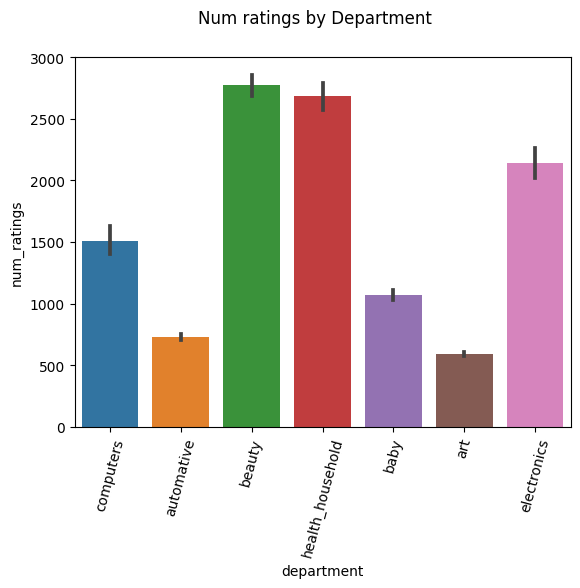

,name,mean_rating,num_ratings,price,division,department
51,amazon basics high-speed hdmi cable for televi...,4.7,517002,9.58,Computer Accessories & Peripherals,computers
327961,"amazon basics high-speed, 4k ultra hd hdmi 2.0...",4.7,516214,6.68,Computers & Accessories,electronics
348489,"amazon basics high-speed hdmi cable, a male to...",4.7,516214,22.21,Television & Video,electronics
317259,ailun for apple iphone 11 pro/xs/x screen prot...,4.6,420199,6.88,Accessories & Supplies,electronics
320495,sandisk 64gb ultra microsdxc uhs-i memory card...,4.7,404694,9.60,Accessories & Supplies,electronics
160860,amazon basics 36-pack aaa alkaline high-perfor...,4.7,383908,13.01,Household Supplies,health_household
49,sandisk 128gb ultra microsdxc uhs-i memory car...,4.7,363512,13.99,Computer Accessories & Peripherals,computers
98088,essence | lash princess false lash effect masc...,4.3,351751,4.99,Makeup,beauty
100410,essence | lash princess volume mascara | cruel...,4.3,351751,14.97,Makeup,beauty
319505,sandisk 256gb extreme microsdxc uhs-i memory c...,4.8,344869,25.64,Accessories & Supplies,electronics


In [53]:
# Which is the most rated product?
top_10_most_rated = df.sort_values(by='num_ratings', ascending=False).head(10)

# Which is the most rated department?
sns.barplot(data=df, x='department', y = 'num_ratings')
plt.suptitle("Num ratings by Department")
plt.xticks(rotation=75)
plt.show()

# LIke top 10 most expensive, the plot won't look great
top_10_most_rated

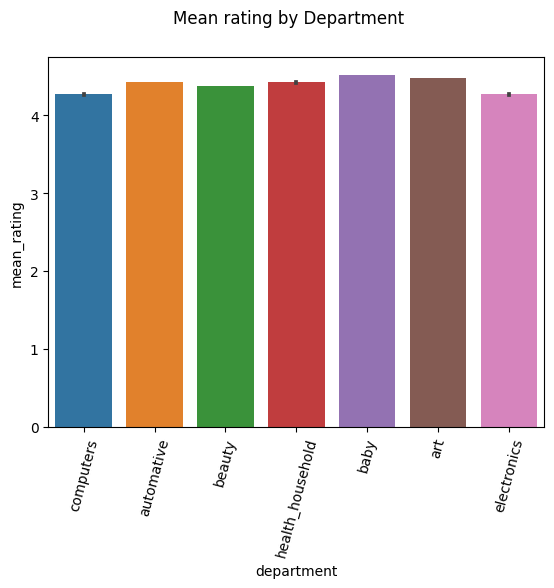

,name,mean_rating,num_ratings,price,division,department
365162,kwmobile cover compatible with kobo libra h2o ...,5.0,3,12.99,eBook Readers & Accessories,electronics
273971,ashley collett design fairy dust 21 fat quarte...,5.0,1,55.40,Fabric,art
273992,mixweer 2 pcs rainbow fabric for bulletin boar...,5.0,1,11.99,Fabric,art
273993,"benecreat 2yard black mesh fabric, polyester h...",5.0,3,19.39,Fabric,art
273994,jill howarth tiny treaters 5 inch stacker 42 5...,5.0,7,13.48,Fabric,art
273997,"woolies flannel three cheers - 40-2.5"" strips ...",5.0,1,53.76,Fabric,art
274009,rastogi handicrafts cotton fabric printed hand...,5.0,3,10.50,Fabric,art
274012,stonehenge gradations brights sunglow stone st...,5.0,18,49.00,Fabric,art
274018,united states flag american flag cotton fabric...,5.0,1,17.09,Fabric,art
274021,blue snow frosty ice blue - wool felt oversize...,5.0,3,8.21,Fabric,art


In [54]:
# Which product has the highest mean rating?

# Which department has the highest mean rating?
sns.barplot(data=df, x='department', y = 'mean_rating')
plt.suptitle("Mean rating by Department")
plt.xticks(rotation=75)
plt.show()

# Which product has the highest mean rating
top_10_mean_rating = df.sort_values(by='mean_rating', ascending=False).head(10)
top_10_mean_rating

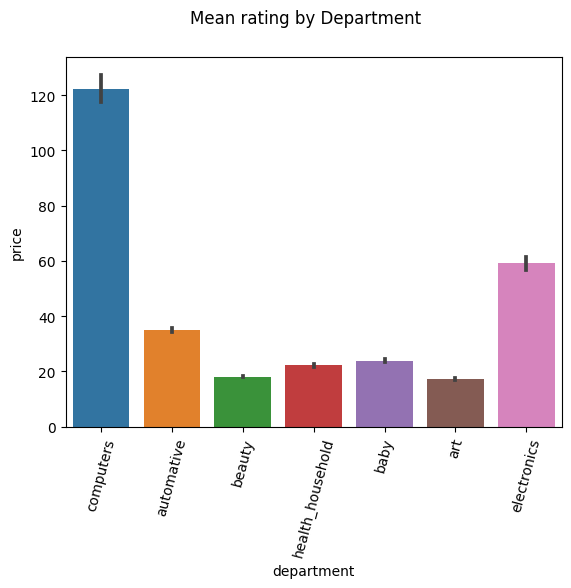

,name,mean_rating,num_ratings,price,division,department
235525,"babebay crib sheets for boys and girls, fitted...",5.0,125,24.99,Nursery,baby
353514,"smart watch, 2023 fitness tracker watch for me...",5.0,238,49.99,Wearable Technology,electronics
18289,2023 new upgrade wifi extender booster repeate...,5.0,15822,59.98,Networking Products,computers
317553,tagry ear buds bluetooth headphones wireless e...,5.0,301,25.99,Accessories & Supplies,electronics
194128,ariat infant baby lil' stompers western boots,5.0,101,25.00,Apparel & Accessories,baby
160672,"cordless heating pad for back pain relief, 800...",5.0,130,47.99,Health Care,health_household
243227,daniel smith 284600065 extra fine watercolor 1...,5.0,491,12.45,"Painting, Drawing & Art Supplies",art
142696,"purple toothpaste for teeth whitening, purple ...",5.0,155,17.99,Personal Care,beauty
78962,convtoya tire inflator portable air compressor...,5.0,303,89.99,Tires & Wheels,automative
160772,neupu 240+lbs plantar fasciitis insoles men wo...,5.0,107,24.99,Health Care,health_household


In [55]:
# Set the threshold for minimum number of ratings
min_num_ratings = 100

# Apply a filter to consider only products with at least min_num_ratings ratings
highly_rated_products = df[df['num_ratings'] >= min_num_ratings]

# Which is the most expensive department in the data?
sns.barplot(data=highly_rated_products, x='department', y = 'price')
plt.suptitle("Mean rating by Department")
plt.xticks(rotation=75)
plt.show()

# Sort the highly rated products by mean rating in descending order
top_highly_rated = highly_rated_products.sort_values(by='mean_rating', ascending=False)

# Display the top highly rated products
top_highly_rated.head(10)

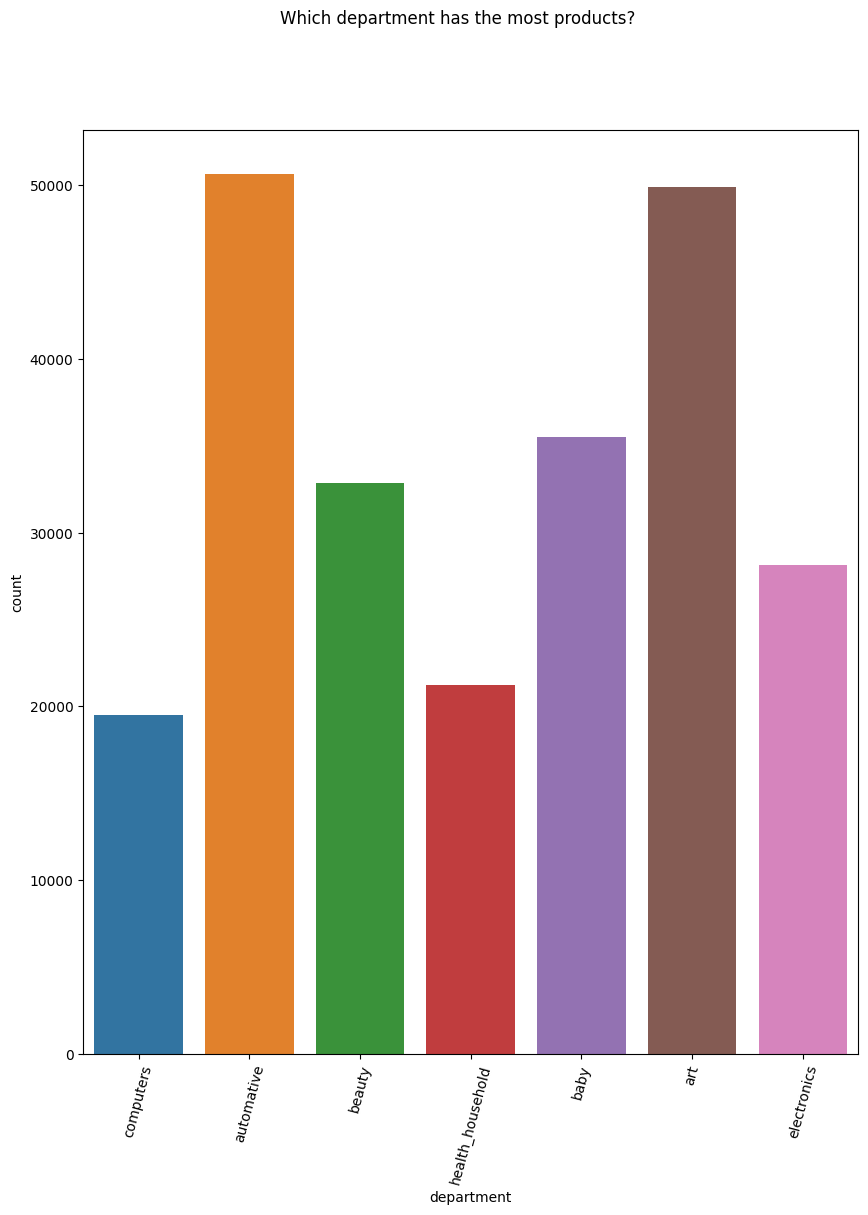

In [64]:
# Which department has the most products?
df.groupby(['department'])['name'].count().sort_values(ascending=False)

plt.figure(figsize=(10, 12))
plt.suptitle("Which department has the most products?")
plt.xticks(rotation=75)
sns.countplot(data=df, x='department')
plt.show()

### Observations:
* Some of the products that have a high mean rating and price have a very low `num_ratings`.
* The **electronics** department is the most rated among the departments.
* The most expensive product is a sony vpl video projector.
* The most rated product is an amazon basics hdmi cable.
* Over 10 products tie for the top 10 rated products.
* **automative** department has the most products followed by art.

## Feature Extraction

In [61]:
# Apply spacy nlp on corpus
df['text_vectors'] = df['name'].apply(lambda x: nlp(x).vector)

# preview
df

,name,mean_rating,num_ratings,price,division,department,text_vectors
0,"usb 3.0 hub, intpw 4 port usb 3.0 hub multipor...",4.5,56,8.39,Computer Accessories & Peripherals,computers,"[-0.03515086, -0.59134907, 0.11526708, 0.05219..."
1,"imegny rgb gaming mouse pad,900x400mm xxxl ext...",4.8,41,20.99,Computer Accessories & Peripherals,computers,"[0.04501152, -0.3549482, 0.21183003, 0.0423579..."
2,eazy2hd 15u open frame network rack for server...,3.9,3,129.99,Computer Accessories & Peripherals,computers,"[-0.014090011, -0.316954, -0.13803811, -0.1828..."
3,"elebase usb to usb c adapter 4 pack,type c fem...",4.6,32687,9.99,Computer Accessories & Peripherals,computers,"[-0.26352262, -0.4533862, 0.08609226, 0.213615..."
4,hp 63xl black high-yield ink cartridge | works...,4.7,49778,45.89,Computer Accessories & Peripherals,computers,"[-0.07858726, -0.2915894, 0.082695544, 0.03236..."
...,...,...,...,...,...,...,...
365155,boxwave case compatible with pocketbook touch ...,5.0,1,25.95,eBook Readers & Accessories,electronics,"[0.04294596, -0.57154596, 0.26557347, 0.099272..."
365156,pocketbook cover for inkpad x | black | pu lea...,3.9,7,21.13,eBook Readers & Accessories,electronics,"[-0.36236426, -0.7287031, 0.51330507, -0.34143..."
365157,kwmobile case compatible with kobo libra h2o -...,4.7,5,12.99,eBook Readers & Accessories,electronics,"[0.0063955993, -0.61206895, 0.5921066, 0.09906..."
365158,kwmobile case compatible with kobo libra 2 cas...,4.1,13,11.99,eBook Readers & Accessories,electronics,"[-0.08521726, -0.60051185, 0.4310241, 0.075531..."


In [65]:
df['text_vectors']

0         [-0.03515086, -0.59134907, 0.11526708, 0.05219...
1         [0.04501152, -0.3549482, 0.21183003, 0.0423579...
2         [-0.014090011, -0.316954, -0.13803811, -0.1828...
3         [-0.26352262, -0.4533862, 0.08609226, 0.213615...
4         [-0.07858726, -0.2915894, 0.082695544, 0.03236...
                                ...                        
365155    [0.04294596, -0.57154596, 0.26557347, 0.099272...
365156    [-0.36236426, -0.7287031, 0.51330507, -0.34143...
365157    [0.0063955993, -0.61206895, 0.5921066, 0.09906...
365158    [-0.08521726, -0.60051185, 0.4310241, 0.075531...
365162    [-0.045603514, -0.5025038, 0.32830873, 0.10671...
Name: text_vectors, Length: 237858, dtype: object

## Load
> Loading the data to the s3 bucket

In [66]:
# export to s3
export_data_to_s3(df, 'scraped_prods_vectorized.csv')

Dataframe is saved as CSV in S3 bucket.
